In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from stochastic_dynamics.models import DeepLagEmbed
from stochastic_dynamics.generators import tvar
from stochastic_dynamics.utils import train_loop, bench_loop
from stochastic_dynamics.plottings import plot_history, plot_coefficients_by_p, plot_tvar_sample
from torchinfo import summary

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DeepLagEmbed(nn.Module):
    def __init__(self, seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128):
        """
        Args:
            seq_len: Length of input sequence
            n_classes: Number of AR order classes (5 for p∈{2,3,4,5,6})
            max_ar_order: Maximum AR order for coefficient output (6 for AR(6))
            hidden_dim: Hidden layer dimension
        """
        super().__init__()
        self.seq_len = seq_len
        self.n_classes = n_classes
        self.max_ar_order = max_ar_order
        
        # P-Block: predicts order class (n_classes outputs)
        self.p_block = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_classes)
        )
        
        # D-Block: (N, seq_len + n_classes) -> (N, seq_len * max_ar_order)
        self.d_block = nn.Sequential(
            nn.Linear(seq_len + n_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, seq_len * max_ar_order)
        )
    
    def forward(self, x, temperature=1.0):
        # x: (N, seq_len)
        N = x.shape[0]
        
        # P-Block: predict class (0 to n_classes-1)
        p_logits = self.p_block(x)  # (N, n_classes)
        p_soft = F.gumbel_softmax(p_logits, tau=temperature, hard=True)  # (N, n_classes)
        p_hard = torch.argmax(p_soft, dim=-1)  # (N,) values in [0, n_classes-1]
        
        # Convert class to AR order: class 0 -> p=2, class 4 -> p=6
        # So we need (p_hard + 2) coefficients active
        # Mask: indices 0...(p_hard+1) should be active
        indices = torch.arange(self.max_ar_order, device=x.device).unsqueeze(0)  # (1, max_ar_order)
        mask = (indices <= p_hard.unsqueeze(1) + 1).float()  # (N, max_ar_order)
        
        # D-Block: concat x and p_soft
        d_input = torch.cat([x, p_soft], dim=1)  # (N, seq_len + n_classes)
        coeffs_raw = self.d_block(d_input)  # (N, seq_len * max_ar_order)
        coeffs_raw = coeffs_raw.view(N, self.seq_len, self.max_ar_order)  # (N, seq_len, max_ar_order)
        
        # Apply mask
        coeffs = coeffs_raw * mask.unsqueeze(1)  # (N, seq_len, max_ar_order)
        
        # Vectorized AR: build lag matrix and do batch matmul
        # x_lagged[:, t, k] = x[:, t - k - 1]
        x_lagged = torch.zeros(N, self.seq_len, self.max_ar_order, device=x.device)
        for k in range(self.max_ar_order):
            x_lagged[:, k+1:, k] = x[:, :self.seq_len - k - 1]
        
        # x_hat[n, t] = sum_k coeffs[n, t, k] * x_lagged[n, t, k]
        x_hat = (coeffs * x_lagged).sum(dim=-1)  # (N, seq_len)
        
        return coeffs, p_logits, p_hard, x_hat


In [3]:
def load_dataset_npz(path):
    d = np.load(path, allow_pickle=True)
    return {
        "X": d["X"],
        "A": d["A"],
        "p_true": d["p_true"],
        "class_id": d["class_id"],
        "class_names": d["class_names"],
        "noise_std": d["noise_std"],
        "meta": list(d["meta"]),
    }

def pinn_processor(npz_path, family=None, p_min=1, train_split=0.8, random_state=42):
    """
    Load a saved TVAR benchmark dataset and return stratified train/val arrays.
    
    Args
    ----
    npz_path : str
        Path to the .npz file saved by save_dataset_npz().
    family : str or None
        The class/family name to filter by. If None, use full dataset.
    p_min : int
        Minimum AR order used when generating the dataset. 
        Used to compute 0-indexed class labels for cross entropy.
    train_split : float
        Fraction of data to use for training (default 0.8 for 80/20 split).
    random_state : int
        Random seed for reproducibility.
    
    Returns
    -------
    X_train, X_val : arrays, shape [N_train, T], [N_val, T]
        Time series samples for train and validation.
    coeffs_train, coeffs_val : arrays, shape [N_train, T, p_max], [N_val, T, p_max]
        Time-varying AR coefficients for train and validation.
    p_train, p_val : arrays, shape [N_train], [N_val]
        True AR order for each sample, 0-indexed for cross entropy.
    class_id_train, class_id_val : arrays, shape [N_train], [N_val]
        Class/family ID for each sample.
    class_names : array
        Names of each class/family.
    """
    dataset = load_dataset_npz(npz_path)
    class_names = dataset["class_names"]

    # Use full dataset if no family specified, otherwise filter by family
    if family is None or family == '':
        X = dataset["X"][:]
        coeffs = dataset["A"][:]
        p_true_raw = dataset["p_true"][:]
        class_id = dataset["class_id"][:]
    else:
        datasets_by_class = {}
        for i, classname in enumerate(class_names):
            mask = dataset["class_id"] == i
            datasets_by_class[classname] = {
                "X": dataset["X"][mask],
                "A": dataset["A"][mask],
                "p_true": dataset["p_true"][mask],
                "class_id": dataset["class_id"][mask],
            }
        subdata = datasets_by_class[family]
        X = subdata["X"][:]
        coeffs = subdata["A"][:]
        p_true_raw = subdata["p_true"][:]
        class_id = subdata["class_id"][:]
    
    # Convert p_true to 0-indexed labels for cross entropy loss
    unique_p = np.sort(np.unique(p_true_raw))
    p_to_idx = {int(p): i for i, p in enumerate(unique_p)}
    p_true = np.array([p_to_idx[int(p)] for p in p_true_raw], dtype=np.int64)
    
    # Stratified train/val split to maintain balanced p distribution
    indices = np.arange(len(X))
    train_idx, val_idx = train_test_split(
        indices, 
        train_size=train_split, 
        stratify=p_true,  # Ensures balanced p values in both splits
        random_state=random_state
    )
    
    X_train, X_val = X[train_idx], X[val_idx]
    coeffs_train, coeffs_val = coeffs[train_idx], coeffs[val_idx]
    p_train, p_val = p_true[train_idx], p_true[val_idx]
    class_id_train, class_id_val = class_id[train_idx], class_id[val_idx]
    
    # Print distribution info
    print(f"Total samples: {len(X)} | Train: {len(X_train)} | Val: {len(X_val)}")
    print(f"Train p distribution: {dict(zip(*np.unique(p_train, return_counts=True)))}")
    print(f"Val p distribution:   {dict(zip(*np.unique(p_val, return_counts=True)))}")
    
    return X_train, coeffs_train, p_train, class_id_train, X_val, coeffs_val, p_val, class_id_val, class_names

In [4]:
data = "train_data.npz"
X_train, coef_train, p_train, class_id_train, X_val, coef_val, p_val, class_id_val, class_names = pinn_processor(data, family=None)

Total samples: 1000000 | Train: 800000 | Val: 200000
Train p distribution: {np.int64(0): np.int64(160000), np.int64(1): np.int64(160000), np.int64(2): np.int64(160000), np.int64(3): np.int64(160000), np.int64(4): np.int64(160000)}
Val p distribution:   {np.int64(0): np.int64(40000), np.int64(1): np.int64(40000), np.int64(2): np.int64(40000), np.int64(3): np.int64(40000), np.int64(4): np.int64(40000)}


In [5]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init()
print(f"Using device: {device}")

# Keep tensors on CPU - DataLoader will batch and pin_memory handles efficient GPU transfer
X_train = torch.tensor(X_train, dtype=torch.float32)
p_train = torch.tensor(p_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
p_val = torch.tensor(p_val, dtype=torch.long)
# Keep class_id as numpy for indexing later
class_id_val = class_id_val  # numpy array

# Use pin_memory for faster CPU->GPU transfer, num_workers for parallel data loading
train_loader = DataLoader(
    TensorDataset(X_train, p_train), 
    batch_size=256,  # Larger batch for big dataset
    shuffle=True, 
    pin_memory=True, 
    num_workers=4
)
val_loader = DataLoader(
    TensorDataset(X_val, p_val), 
    batch_size=256, 
    pin_memory=True, 
    num_workers=4
)

Using device: cuda:1


In [6]:
def do_bench_on_config(lambda_config):
    
    # hyperparameters
    n_epochs = 100
    lr = 1e-3
    max_ar_order = 6
    

    # Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
    model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
    model = model.to(device)

    # summary(model, input_size=(32, 600), device=device)

    # Train
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], lambda_ar=lambda_config["lambda_ar"], lambda_energy=lambda_config["lambda_energy"], 
        lambda_smooth=lambda_config["lambda_smooth"], lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    return model, history

Training: 100%|██████████| 100/100 [13:21<00:00,  8.01s/it, p_acc=0.340, train=6.6158, val=8.4091]


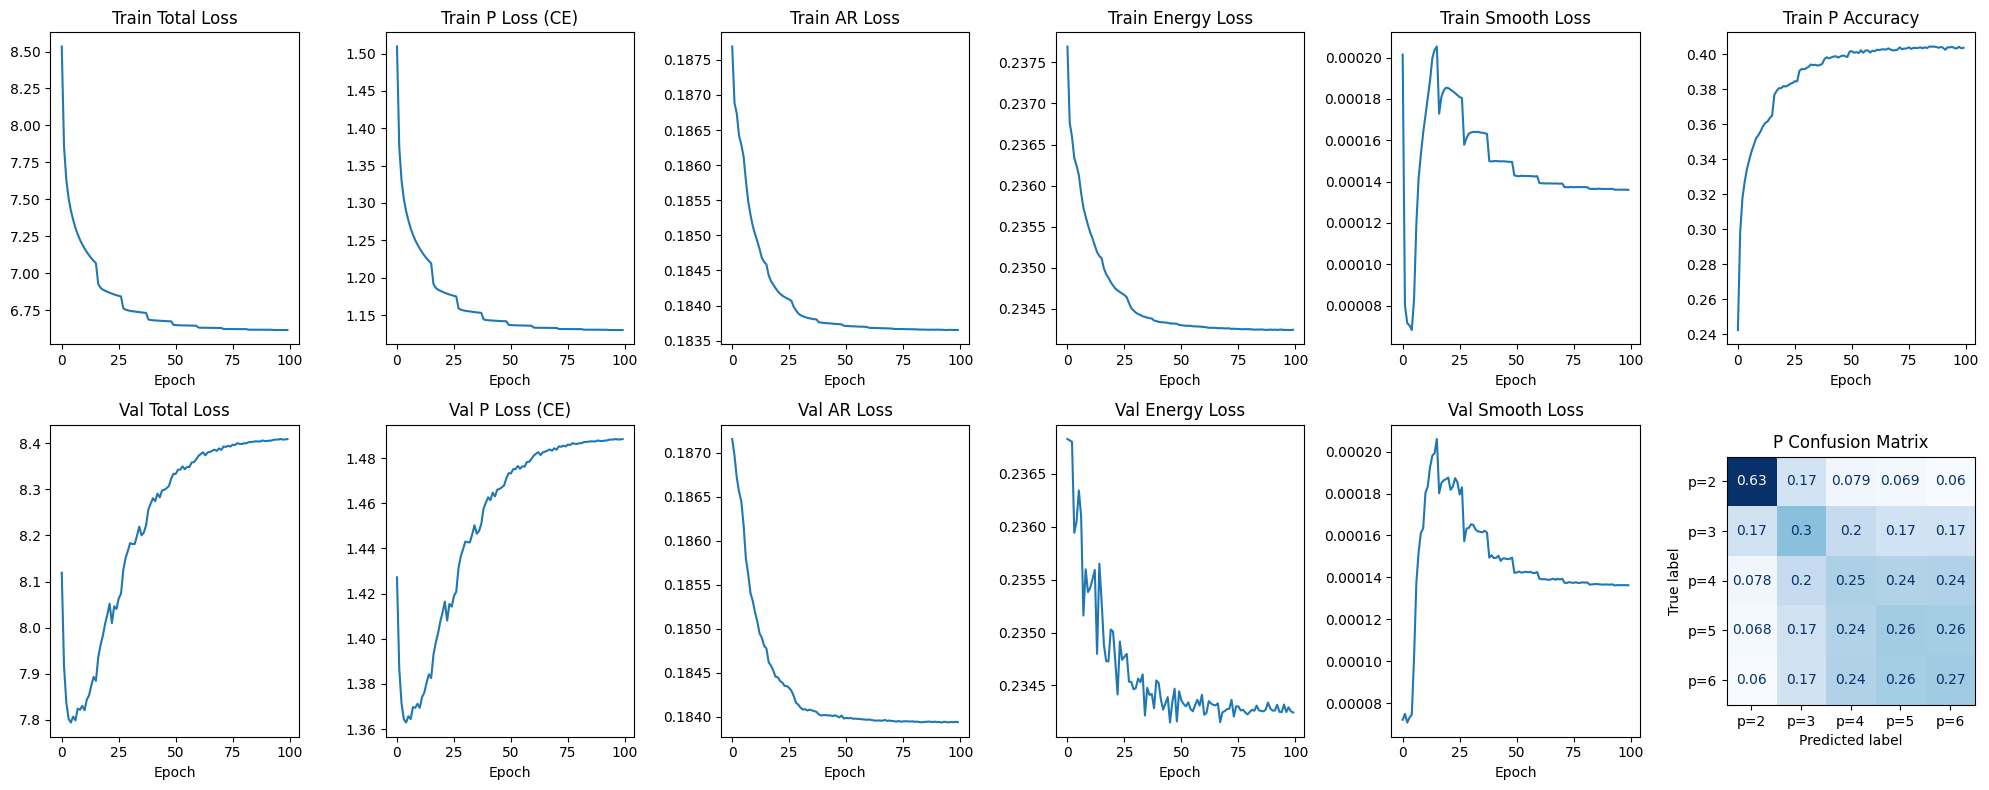

coeff_mse: 0.004300462547689676
signal_mse: 0.18393586575984955
p_mae: 1.120105
p_mape: 0.3036664166666667
p2_acc: 0.6222
p3_acc: 0.29555
p4_acc: 0.24305
p5_acc: 0.25695
p6_acc: 0.27
p_acc: 0.33755


In [7]:
conf = {
    "lambda_ar": 5,
    "lambda_p": 5,
    "lambda_order": 0,
    "lambda_energy": 0.2,
    "lambda_smooth": 5,
}

model, history = do_bench_on_config(conf)
plot_history(history, model=model, val_loader=val_loader, device=device)
# Slice coef_val to match model output dimension (max_ar_order=6)
full_bench_results = bench_loop(model, X_val, coef_val[:, :, :6], p_val, device)
for k, v in full_bench_results.items():
    print(f"{k}: {v}")

In [8]:
import pandas as pd

ablation_df = pd.DataFrame({
    'full': full_bench_results,
}).T

ablation_df

,coeff_mse,signal_mse,p_mae,p_mape,p2_acc,p3_acc,p4_acc,p5_acc,p6_acc,p_acc
full,0.0043,0.183936,1.120105,0.303666,0.6222,0.29555,0.24305,0.25695,0.27,0.33755


In [9]:
# Get predictions on full validation set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_p_pred = []
all_p_true = []

with torch.no_grad():
    for x_batch, p_batch in tqdm(val_loader, desc="Getting predictions"):
        x_batch = x_batch.to(device)
        _, _, p_hard, _ = model(x_batch)
        all_p_pred.extend(p_hard.cpu().numpy())
        all_p_true.extend(p_batch.numpy())

all_p_pred = np.array(all_p_pred)
all_p_true = np.array(all_p_true)

Getting predictions: 100%|██████████| 782/782 [00:00<00:00, 834.28it/s] 


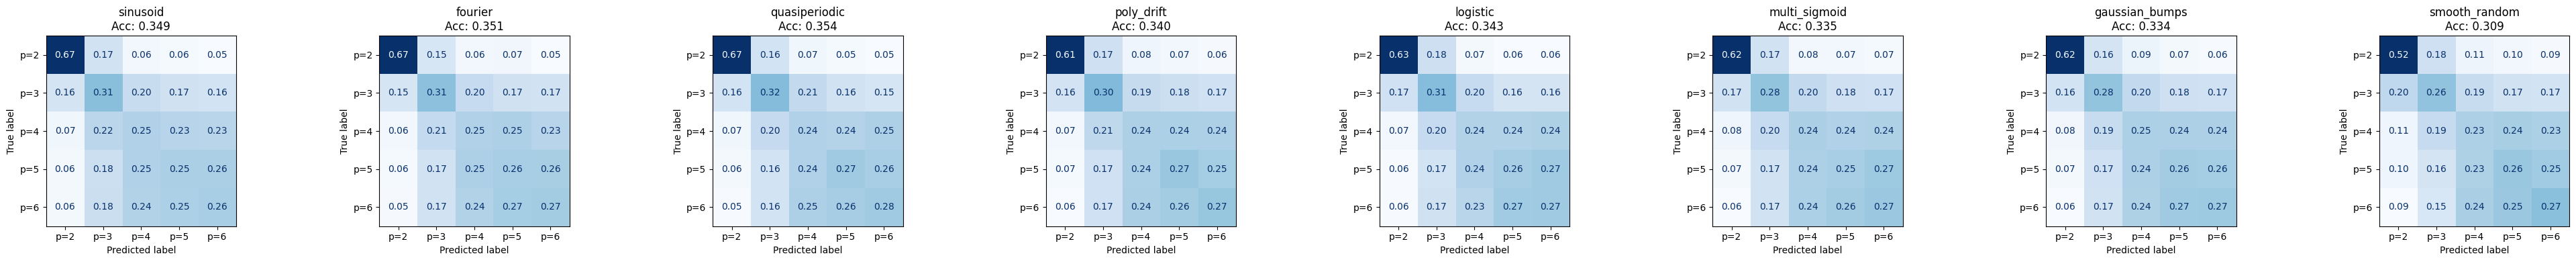


Per-family accuracy:
  sinusoid: 0.3487 (n=25163)
  fourier: 0.3514 (n=24912)
  quasiperiodic: 0.3545 (n=25049)
  poly_drift: 0.3401 (n=25041)
  logistic: 0.3426 (n=24961)
  multi_sigmoid: 0.3346 (n=25106)
  gaussian_bumps: 0.3338 (n=24834)
  smooth_random: 0.3092 (n=24934)


In [10]:
# Plot confusion matrix for each signal family
n_families = len(class_names)
fig, axes = plt.subplots(1, n_families, figsize=(5 * n_families, 4))

p_min, p_max = 2, 6
n_classes = p_max - p_min + 1

family_results = {}

for i, family_name in enumerate(class_names):
    mask = class_id_val == i
    p_true_family = all_p_true[mask]
    p_pred_family = all_p_pred[mask]
    
    # Compute normalized confusion matrix
    cm = confusion_matrix(p_true_family, p_pred_family, labels=range(n_classes))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    
    # Store accuracy for this family
    family_results[family_name] = {
        'accuracy': np.mean(p_true_family == p_pred_family),
        'n_samples': len(p_true_family)
    }
    
    # Plot
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=[f'p={j+p_min}' for j in range(n_classes)])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='.2f')
    axes[i].set_title(f'{family_name}\nAcc: {family_results[family_name]["accuracy"]:.3f}')

plt.tight_layout()
plt.show()

# Print summary
print("\nPer-family accuracy:")
for name, res in family_results.items():
    print(f"  {name}: {res['accuracy']:.4f} (n={res['n_samples']})")

In [11]:
# Per-family benchmark results (AR coefficient accuracy, etc.)
from stochastic_dynamics.utils import bench_loop

family_bench_results = {}

for i, family_name in enumerate(class_names):
    mask = class_id_val == i
    X_family = X_val[mask]
    coef_family = coef_val[mask][:, :, :6]  # Slice to max_ar_order=6
    p_family = p_val[mask]
    
    results = bench_loop(model, X_family, coef_family, p_family, device)
    family_bench_results[family_name] = results

# Display as DataFrame
family_bench_df = pd.DataFrame(family_bench_results).T
family_bench_df

,coeff_mse,signal_mse,p_mae,p_mape,p2_acc,p3_acc,p4_acc,p5_acc,p6_acc,p_acc
sinusoid,0.003890,0.183033,1.085721,0.289908,0.666472,0.317397,0.238572,0.247545,0.270022,0.349601
fourier,0.004254,0.184072,1.073298,0.285962,0.666531,0.318604,0.256680,0.263994,0.266222,0.353123
quasiperiodic,0.004003,0.182122,1.079404,0.286716,0.667549,0.302075,0.246517,0.264155,0.265229,0.347718
poly_drift,0.004274,0.183775,1.131544,0.309123,0.611855,0.302807,0.240032,0.257887,0.269063,0.337367
logistic,0.003645,0.183010,1.102760,0.297779,0.638277,0.305031,0.246553,0.270610,0.268322,0.346460
multi_sigmoid,0.003136,0.182469,1.130606,0.307832,0.616371,0.277476,0.236623,0.255332,0.258576,0.329523
gaussian_bumps,0.003518,0.183866,1.134010,0.308249,0.614911,0.282697,0.237837,0.257058,0.271789,0.331441
smooth_random,0.007688,0.189217,1.230729,0.344367,0.517807,0.257183,0.230877,0.253280,0.264789,0.304885


In [12]:
def plot_coefficients_by_p(model, X, coeffs_true, p_true, device, p_max=6, p_min=2, title=""):
    model.eval()
    
    n_classes = p_max - p_min + 1  # 5 classes for p=2,3,4,5,6
    fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4))
    
    with torch.no_grad():
        for p_idx in range(n_classes):
            ax = axes[p_idx]
            p_actual = p_idx + p_min  # True AR order: 2,3,4,5,6
            
            mask = (p_true == p_idx).numpy() if torch.is_tensor(p_true) else (p_true == p_idx)
            if not mask.any():
                ax.set_title(f'p={p_actual} (no example)')
                continue
            
            idx = np.where(mask)[0][0]
            
            if torch.is_tensor(X):
                x = X[idx:idx+1].clone().detach().to(device)
            else:
                x = torch.from_numpy(X[idx:idx+1]).float().to(device)
            
            coeffs_pred, _, p_hard, _ = model(x)
            coeffs_pred = coeffs_pred.cpu().numpy()[0]  # (600, max_ar_order)
            p_pred = p_hard.item() + p_min  # Predicted AR order
            
            # Plot true coefficients (p_actual of them)
            for k in range(p_actual):
                label = 'True' if k == 0 else None
                ax.plot(coeffs_true[idx, :, k], 'k-', alpha=0.7, label=label)
            
            # Plot predicted coefficients (p_pred of them)
            for k in range(p_pred):
                label = 'Pred' if k == 0 else None
                ax.plot(coeffs_pred[:, k], color='darkred', alpha=0.7, label=label)
            
            ax.set_title(f'True p={p_actual}, Pred p={p_pred}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Coefficient')
            ax.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

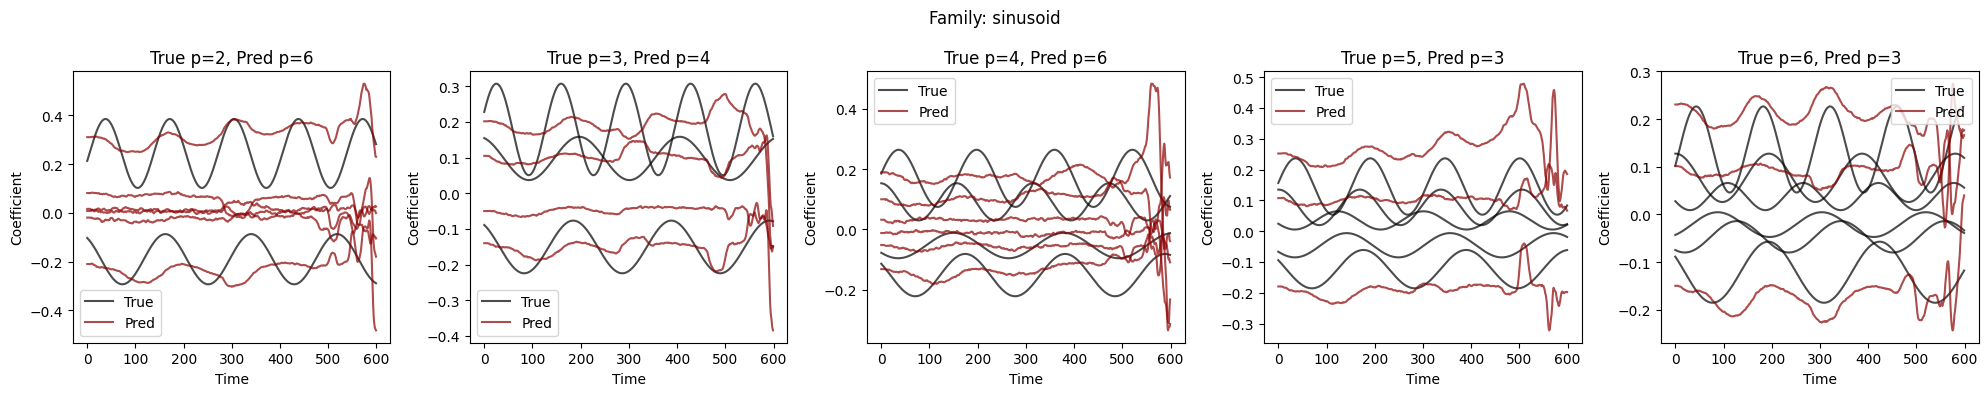

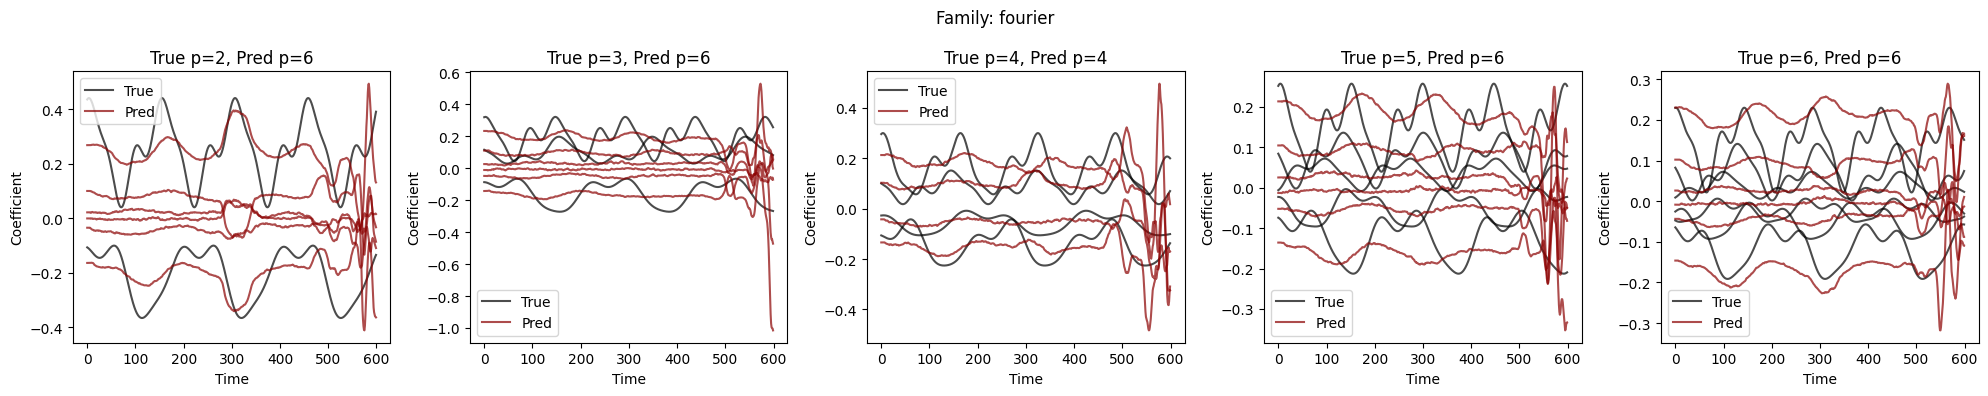

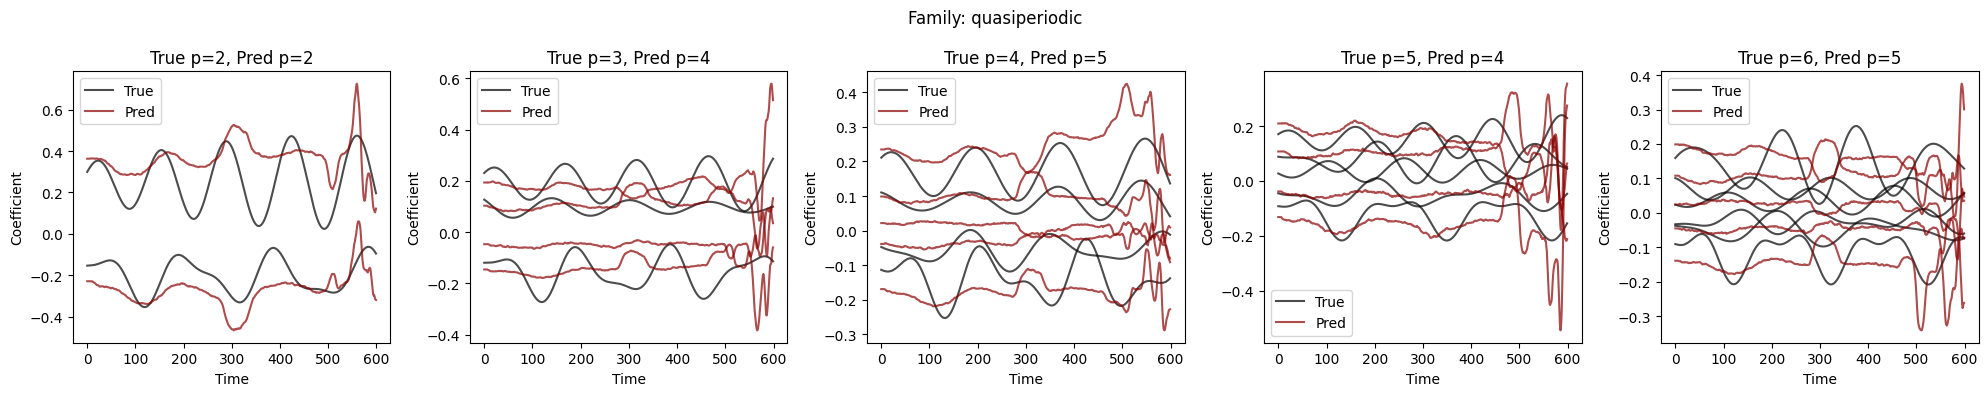

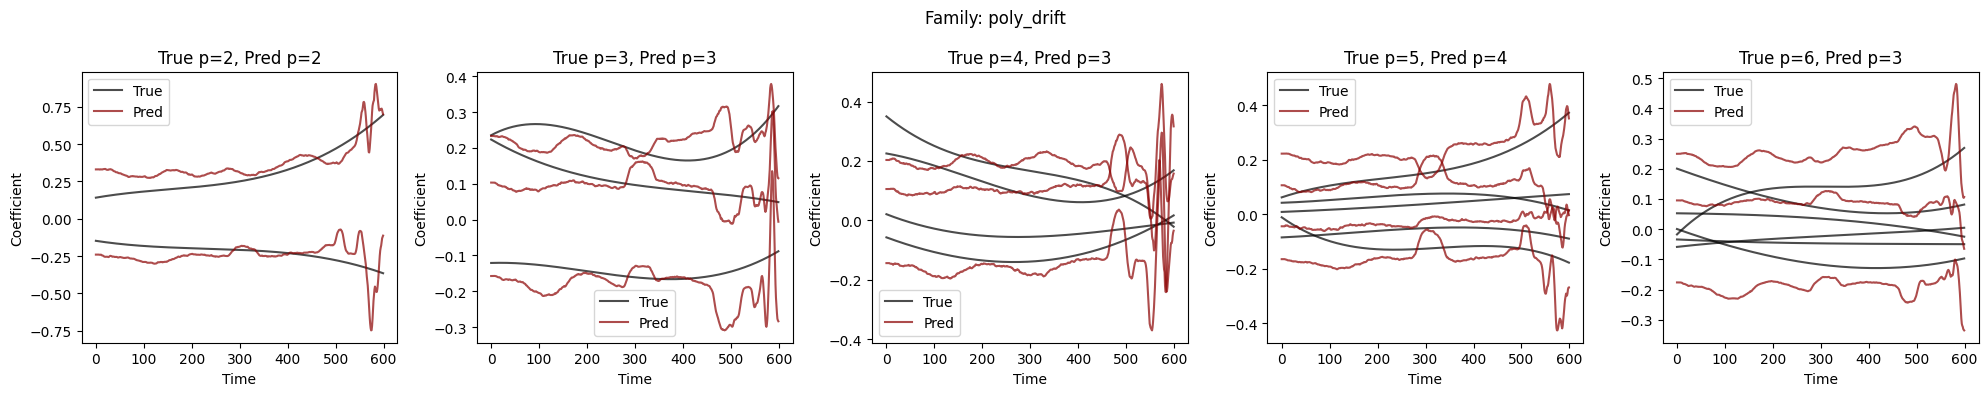

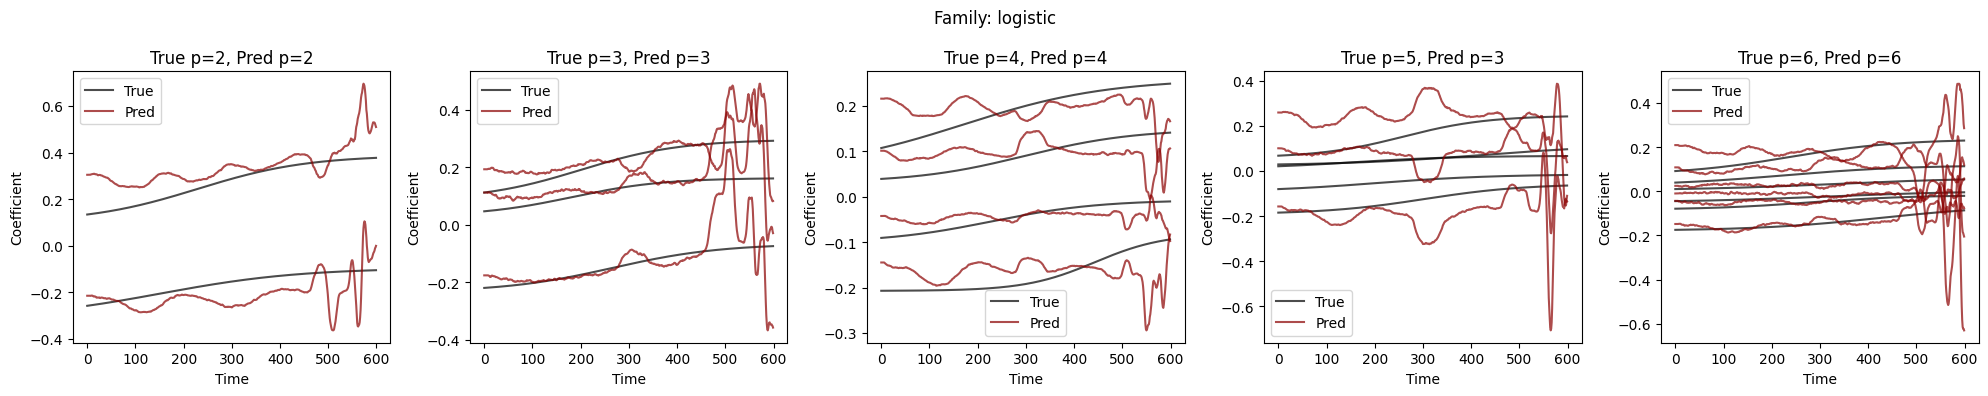

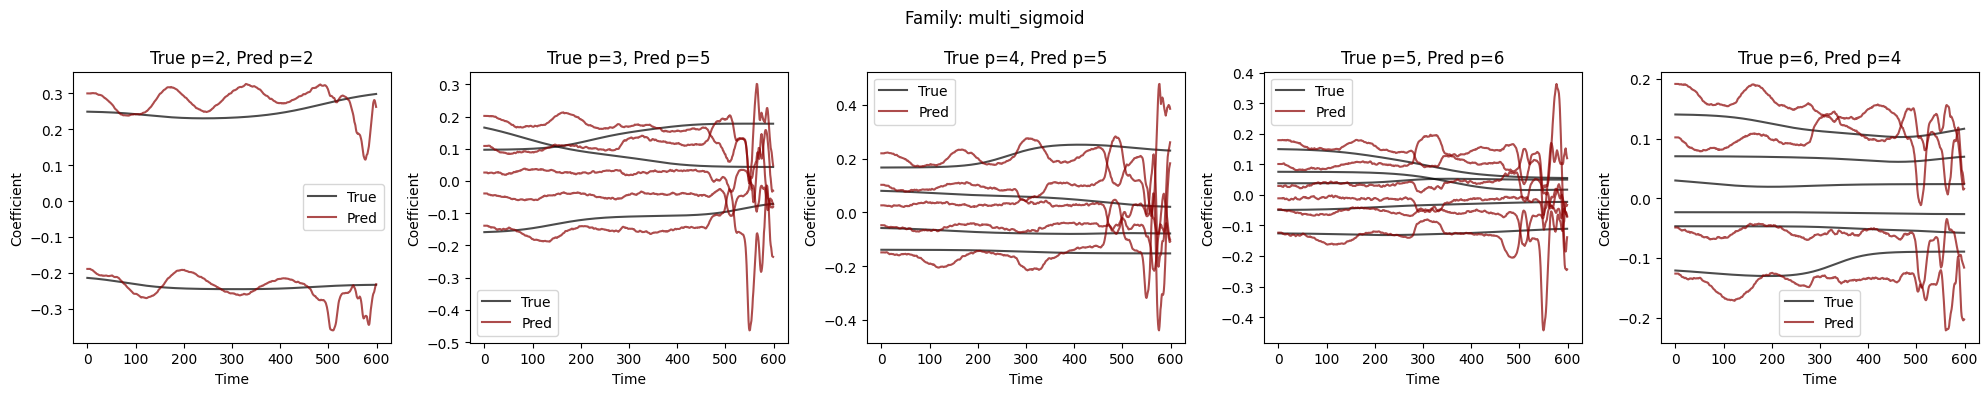

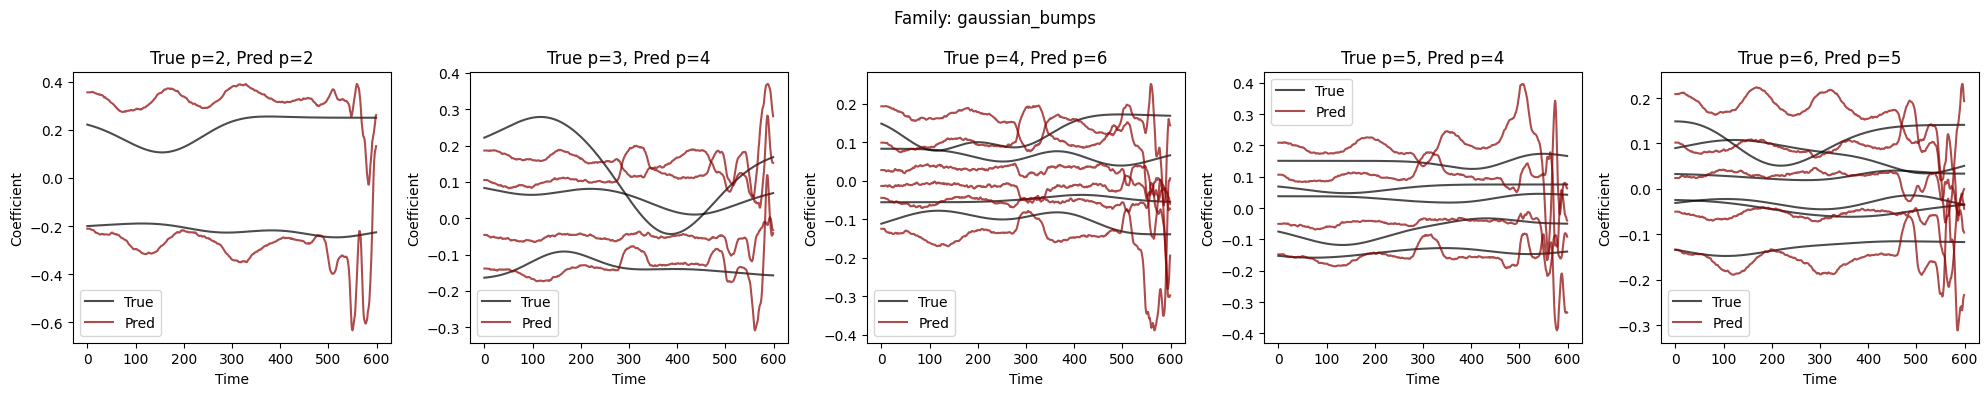

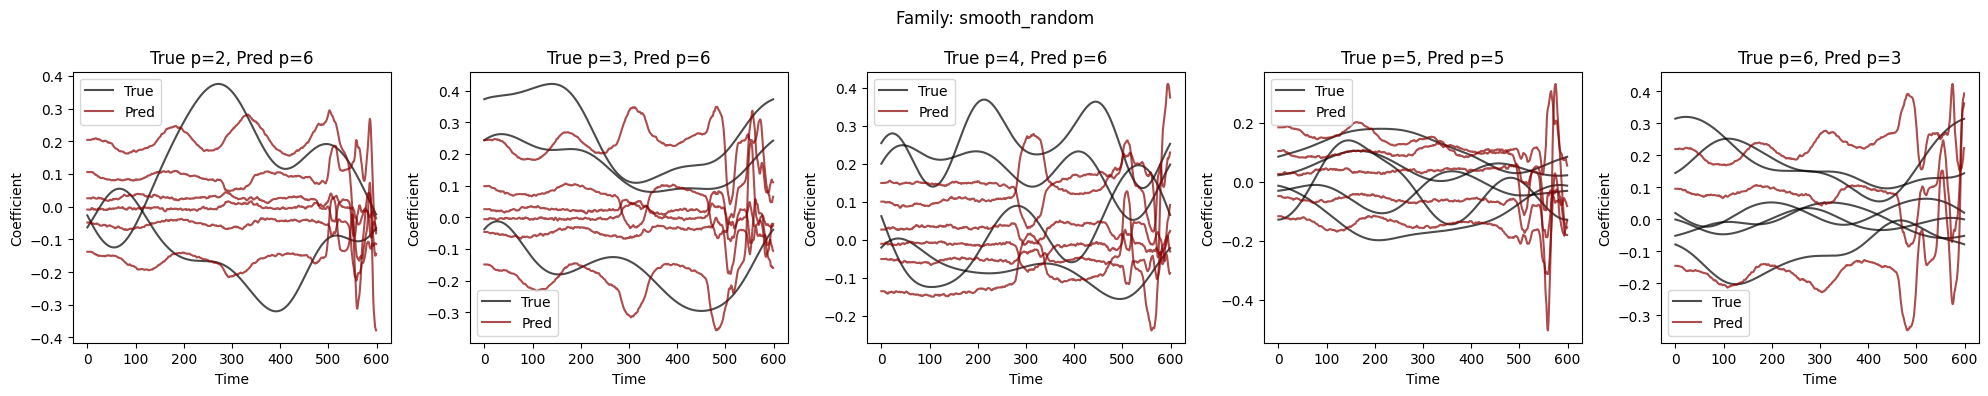

In [13]:
# Plot coefficient predictions for each signal family
for i, family_name in enumerate(class_names):
    mask = class_id_val == i
    X_family = X_val[mask]
    coef_family = coef_val[mask][:, :, :6]
    p_family = p_val[mask]
    
    plot_coefficients_by_p(model, X_family, coef_family, p_family, device, 
                           p_max=6, p_min=2, title=f"Family: {family_name}")